# CANCER REG

Hemos de responder a las siguientes preguntas:

1. ¿Qué variables parecen tener un mayor impacto sobre la tasa de mortalidad del análisis estadístico?, ¿Cómo podemos validarlo?
2. Dentro del modelo de regresión lineal, ¿Qué variables son las que más impacto tienen sobre el modelo?, ¿Cómo de significativas son con respecto al modelo?
3. ¿Cómo se distribuyen los residuos de la regresión?, ¿Qué información se puede extraer de los mismos?

Primero vamos a cargar la data  y realizar un analisis exploratorio de la misma. Para esto, vamos a cargar las librerías necesarias y la data.


## Import librerías and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)

# Load Data
data = pd.read_csv('../data/cancer_reg.csv')

print("The shape of data: ", data.shape)

The shape of data:  (3047, 33)


Bien podemos ver que son muchas variables, vamos a explorar cada una de ellas para saber de que se tratan y así tener una idea de que data tenemos entre manos y que variables pueden ser relevantes para nuestro análisis. Para esto, vamos a utilizar la función `info()` de pandas para obtener información sobre las columnas y sus tipos de datos, y la función `describe()` para obtener estadísticas descriptivas de las variables numéricas.

In [2]:
# Print INFO
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   object 
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  geography                3047 non-null   object 
 13  percentmarried           3047 non-null   float64
 14  pctnohs18_24            

Como no tenemos información disponible sobre el métodos de obtención de los datos y sin conocer el contexto de cada variable, aquellas que tienen valores nulos, debemos descartarlos para la medición.

In [3]:
data.drop(
    columns = ['pctsomecol18_24', 'pctprivatecoveragealone', 'pctsomecol18_24', 'pctemployed16_over'], inplace = True
)

1. **Estadísticas de Cáncer (Variables de Salud)**

`avganncount`: Media de casos de cáncer reportados anualmente en el condado.

`avgdeathsperyear`: Media de muertes anuales atribuidas al cáncer.

`target_deathrate` (Variable Objetivo): Tasa de mortalidad por cáncer por cada 100.000 habitantes. Es el "indicador estrella" que queremos explicar o predecir.

`incidencerate`: Tasa de nuevos diagnósticos por cada 100.000 habitantes.

1. **Factores Socioeconómicos**

`medincome`: Ingreso mediano por hogar. Es la "cartera" promedio de la zona.

`povertypercent`: Porcentaje de la población viviendo bajo el umbral de pobreza.

`binnedinc`: El ingreso mediano clasificado en intervalos (bins). Útil para análisis categóricos.

`studypercap`: Número de estudios clínicos per cápita realizados en la zona.

1. **Demografía**

`popest2015`: Estimación de la población total en el año 2015.

`geography`: Nombre del condado y el estado.

`medianage` / `medianagemale` / `medianagefemale`: Edad mediana total, de hombres y de mujeres.

`birthrate`: Tasa de natalidad.

`percentmarried` / `pctmarriedhouseholds`: Porcentaje de personas casadas y hogares compuestos por parejas casadas.

1. **Educación y Empleo**

`pctnohs18_24` / `pcths18_24` / `pctsomecol18_24` / `pctbachdeg18_24`: Nivel educativo alcanzado por jóvenes de 18 a 24 años (Sin secundaria, secundaria, algo de universidad o título universitario).

`pcths25_over` / `pctbachdeg25_over`: Nivel de estudios (Secundaria o Grado) para mayores de 25 años. Es como medir cuántos "libros" se han leído en el barrio a largo plazo.

`pctemployed16_over` / `pctunemployed16_over`: Porcentaje de la población mayor de 16 años con o sin empleo.

1. **Cobertura Sanitaria y Etnias**

`pctprivatecoverage` / `pctprivatecoveragealone`: Porcentaje con seguro médico privado (total y exclusivo).

`pctpubliccoverage` / `pctpubliccoveragealone`: Porcentaje con cobertura pública (como Medicaid o Medicare). Piensa en esto como la "red de seguridad" estatal.

`pctwhite` / `pctblack` / `pctasian` / `pctotherrace`: Composición étnica de la población.

Vamos a ver como estan los estadisticos principales de cada variable para tener una idea de como son. Para ello, usamos `describe()` de pandas, con esto nos podemos hacer una idea inicial.

In [4]:
# print description
data.describe()

,avganncount,avgdeathsperyear,target_deathrate,incidencerate,medincome,popest2015,povertypercent,studypercap,medianage,medianagemale,medianagefemale,percentmarried,pctnohs18_24,pcths18_24,pctbachdeg18_24,pcths25_over,pctbachdeg25_over,pctunemployed16_over,pctprivatecoverage,pctempprivcoverage,pctpubliccoverage,pctpubliccoveragealone,pctwhite,pctblack,pctasian,pctotherrace,pctmarriedhouseholds,birthrate
count,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3.047000e+03,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000
mean,606.338544,185.965868,178.664063,448.268586,47063.281917,1.026374e+05,16.878175,155.399415,45.272333,39.570725,42.145323,51.773679,18.224450,35.002068,6.158287,34.804660,13.282015,7.852412,64.354939,41.196324,36.252642,19.240072,83.645286,9.107978,1.253965,1.983523,51.243872,5.640306
std,1416.356223,504.134286,27.751511,54.560733,12040.090836,3.290592e+05,6.409087,529.628366,45.304480,5.226017,5.292849,6.896928,8.093064,9.069722,4.529059,7.034924,5.394756,3.452371,10.647057,9.447687,7.841741,6.113041,16.380025,14.534538,2.610276,3.517710,6.572814,1.985816
min,6.000000,3.000000,59.700000,201.300000,22640.000000,8.270000e+02,3.200000,0.000000,22.300000,22.400000,22.300000,23.100000,0.000000,0.000000,0.000000,7.500000,2.500000,0.400000,22.300000,13.500000,11.200000,2.600000,10.199155,0.000000,0.000000,0.000000,22.992490,0.000000
25%,76.000000,28.000000,161.200000,420.300000,38882.500000,1.168400e+04,12.150000,0.000000,37.700000,36.350000,39.100000,47.750000,12.800000,29.200000,3.100000,30.400000,9.400000,5.500000,57.200000,34.500000,30.900000,14.850000,77.296180,0.620675,0.254199,0.295172,47.763063,4.521419
50%,171.000000,61.000000,178.100000,453.549422,45207.000000,2.664300e+04,15.900000,0.000000,41.000000,39.600000,42.400000,52.400000,17.100000,34.700000,5.400000,35.300000,12.300000,7.600000,65.100000,41.100000,36.300000,18.800000,90.059774,2.247576,0.549812,0.826185,51.669941,5.381478
75%,518.000000,149.000000,195.200000,480.850000,52492.000000,6.867100e+04,20.400000,83.650776,44.000000,42.500000,45.300000,56.400000,22.700000,40.700000,8.200000,39.650000,16.100000,9.700000,72.100000,47.700000,41.550000,23.100000,95.451693,10.509732,1.221037,2.177960,55.395132,6.493677
max,38150.000000,14010.000000,362.800000,1206.900000,125635.000000,1.017029e+07,47.400000,9762.308998,624.000000,64.700000,65.700000,72.500000,64.100000,72.500000,51.800000,54.800000,42.200000,29.400000,92.300000,70.700000,65.100000,46.600000,100.000000,85.947799,42.619425,41.930251,78.075397,21.326165


### 1. ¿Qué variables parecen tener un mayor impacto sobre la tasa de mortalidad del análisis estadístico?, ¿Cómo podemos validarlo?

Hay varias variables que podemos hacer descarte incial, ya que hablan del mismo fenómeno pero desde perspectivas distintas. Un ejemplo claro es `medincome` y `povertypercent`, ambos hablan de la misma situación económica, al igual que `binnedinc` que es una variable categórica del mismo fenómeno pero en agregados de bins. De cualquier forma, podemos realizar un analisis de correlación incial para ver que variables tienen mayor correlación con la variable objetivo `target_deathrate`.

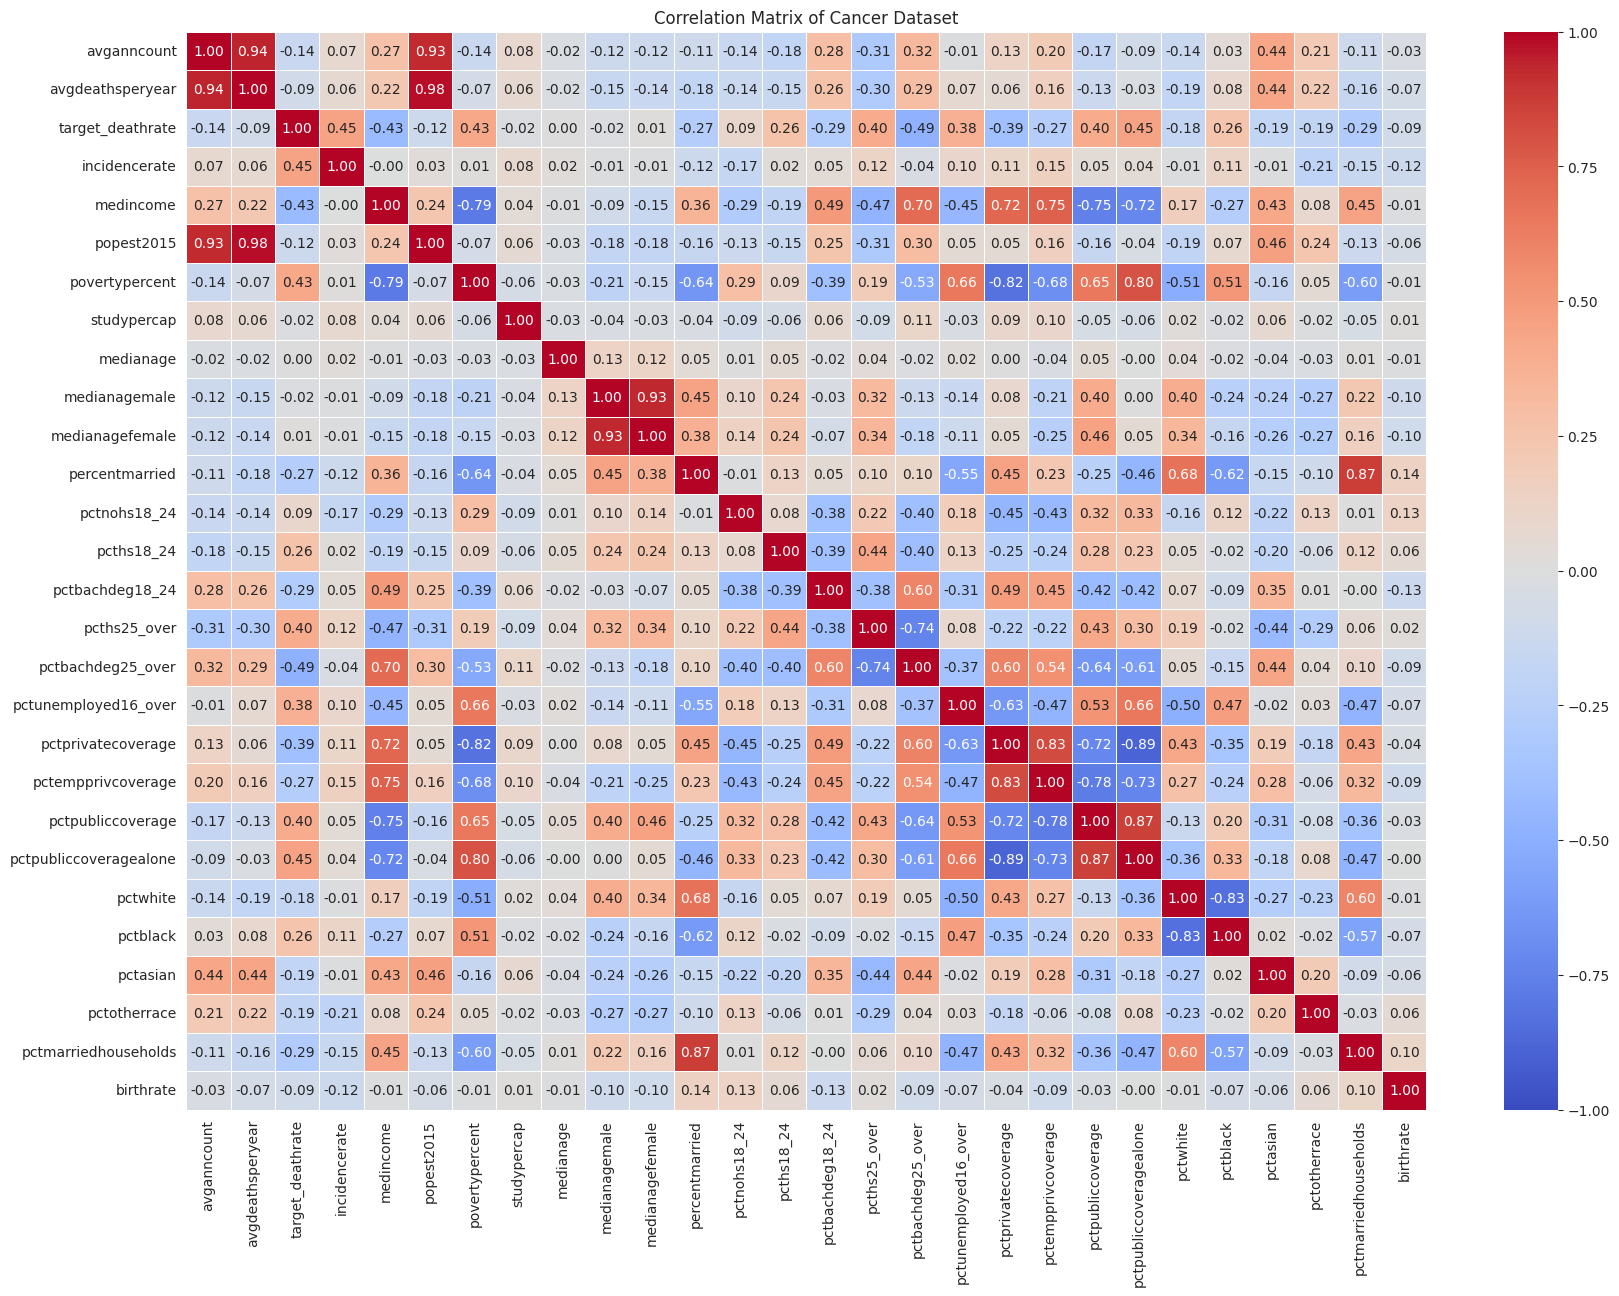

In [5]:
# Plot Correlation Matrix
plt.figure(figsize=(20, 14))

corr_matrix = data.drop( columns = ['binnedinc', 'geography']).corr(method = "pearson")

sns.heatmap(
    # corr_matrix[corr_matrix['target_deathrate'].abs() >= 0.4],
    corr_matrix,
    annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, linecolor='white', 
            # Reduce label size

            )
plt.title('Correlation Matrix of Cancer Dataset')
plt.show()

In [6]:
print("List of features with correlation >= 0.4 or <= -0.4 with target_deathrate: \n")
print(corr_matrix[corr_matrix['target_deathrate'].abs() >= 0.4]['target_deathrate'])

List of features with correlation >= 0.4 or <= -0.4 with target_deathrate: 

target_deathrate          1.000000
incidencerate             0.449432
medincome                -0.428615
povertypercent            0.429389
pcths25_over              0.404589
pctbachdeg25_over        -0.485477
pctpubliccoverage         0.404572
pctpubliccoveragealone    0.449358
Name: target_deathrate, dtype: float64


In [7]:
corr_matrix[corr_matrix['target_deathrate'].abs() >= 0.4]['target_deathrate']

target_deathrate          1.000000
incidencerate             0.449432
medincome                -0.428615
povertypercent            0.429389
pcths25_over              0.404589
pctbachdeg25_over        -0.485477
pctpubliccoverage         0.404572
pctpubliccoveragealone    0.449358
Name: target_deathrate, dtype: float64

Bien, podemos decir que existen ciertas correlaciones fuertes, y aun mas cuando se tratan de datos epidemiologicos o sociales. En este caso, existen correlaciones consideradas fuertes pero alrededor de variables cercanas al `target_Deathrate` como lo es `avgdeathsperyear` o `incidencerate`, los cuales descartamos en este análisis.

Las variabels que pueden aportar correlacion a la variable objetivo son:
- `medincome` (-0.43): Un ingreso mediano más alto se asocia con una tasa de mortalidad por cáncer más baja, lo que sugiere que la riqueza puede ser un factor protector.
- `povertypercent` (0.43) : Un mayor porcentaje de pobreza se asocia con una tasa de mortalidad por cáncer más alta, lo que indica que la pobreza puede ser un factor de riesgo.
- `pcths25_over` (0.40) : Un mayor porcentaje de personas con al menos educación secundaria se asocia con una tasa de mortalidad por cáncer más alta. De hecho podemos encontrar. Podemos encontrar una correlacion a su vez con `medincome` alta.
- `pctbachdeg25_over` (-0.49): Un mayor porcentaje de personas con título universitario se asocia con una tasa de mortalidad por cáncer más baja. A su vez, podemos encontrar una correlacion alta con `medincome` alta.
- `pctemployed16_over` (-0.41): Un mayor porcentaje de personas empleadas se asocia con una tasa de mortalidad por cáncer más baja.
- `pctpubliccoverage` (0.40): Un mayor porcentaje de personas con cobertura pública se asocia con una tasa de mortalidad por cáncer más alta, lo que podría indicar que la cobertura pública está más presente en áreas con mayores necesidades de salud.
- `pctpubliccoveragealone` (0.44): Un mayor porcentaje de personas con cobertura pública exclusiva se asocia con una tasa de mortalidad por cáncer más alta, lo que refuerza la idea de que la cobertura pública puede estar relacionada con áreas de mayor vulnerabilidad.

### 2. Dentro del modelo de regresión lineal, ¿Qué variables son las que más impacto tienen sobre el modelo?, ¿Cómo de significativas son con respecto al modelo?

Primero es importante realizar una seleccion de variables que influyan sobre la variable objetivo, pero esta selección debe de garantizar un nivel de independencia entre estas variables predictoras. Para esto, hagamosuna selccion de variables.

Podemos usar el factor de inflación de la varianza (VIF) para detectar multicolinalidad entre variables de forma mas cuantitativa, aunque hay alguna que ya son bastante intuitivas de determinar.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df):
    X = add_constant(df)
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

vif_result = calculate_vif(data.drop(
    columns = ['binnedinc', 'geography']
    ))


In [9]:
# Print VIF results
print(vif_result)

                   feature          VIF
0                    const  1365.832083
1              avganncount     9.781422
2         avgdeathsperyear    31.574927
3         target_deathrate     2.077763
4            incidencerate     1.561832
5                medincome     7.607314
6               popest2015    26.485582
7           povertypercent     7.939854
8              studypercap     1.045350
9                medianage     1.023924
10           medianagemale     9.664786
11         medianagefemale    10.469080
12          percentmarried     8.288971
13            pctnohs18_24     1.673640
14              pcths18_24     1.628593
15         pctbachdeg18_24     1.960180
16            pcths25_over     3.775800
17       pctbachdeg25_over     5.717067
18    pctunemployed16_over     2.502541
19      pctprivatecoverage    15.847052
20      pctempprivcoverage     7.720959
21       pctpubliccoverage    23.608930
22  pctpubliccoveragealone    22.879244
23                pctwhite     7.100114


Aqui podemos ver claramente como en ciertos casos el VIF es increiblemente grande, como lo puede ser `avgdeathsperyear` o `popest2015`. Curiosamente, `medincome` y `povertypercent` tambien tienen un VIF alto, lo que indica que estas variables estan altamente correlacionadas entre si, lo cual es logico ya que ambas hablan de la misma situacion economica pero desde perspectivas distintas.

`mediaagemale` y `mediaagefemale` tambien tienen un VIF alto, ya que `medianage` ya es una variable que calcula esta media, es normal que si existe una media de edad de hombres creciente, la de mujeres también lo sea. Lo útil entonces es quedarnos con un unicamente `medianage`.

En el mundo de las coberturas de salud, vamos a quedarnos unicamente con la privada no exclusiva `ptcprivatecoverage`, ya que si exsite un bajo porcentaje de esta, pues es supuesto que la publica aumenta hasta en su exclusiva. Son variables que hablan del mismo efecto y existe un solapamiento entre ellas.

En economia y educación, no existe variable mas facil de entender que el ingreso mediano `medincome`. Esta variable se encuentra muy correlacionada con el resto, como el porcentaje de pobreza `povertypercent` y el porcentaje de personas con educación como `pctbachdeg25_over` o `pcths25_over`. Por tanto, vamos a quedarnos unicamente con `medincome` para representar la situación económica y educativa de la zona.

Vamos a empezar a eliminar variables y recalcular el VIF para ver como estas deberían ir estabilizandose.

In [10]:
print(
    calculate_vif(
        data.drop( columns = ['binnedinc', 'geography', 'avgdeathsperyear'])
    )
)

                   feature          VIF
0                    const  1365.732819
1              avganncount     8.071897
2         target_deathrate     2.061291
3            incidencerate     1.561658
4                medincome     7.592938
5               popest2015     8.252526
6           povertypercent     7.812049
7              studypercap     1.045210
8                medianage     1.023531
9            medianagemale     9.661359
10         medianagefemale    10.438143
11          percentmarried     8.224101
12            pctnohs18_24     1.673422
13              pcths18_24     1.628319
14         pctbachdeg18_24     1.954350
15            pcths25_over     3.774747
16       pctbachdeg25_over     5.693792
17    pctunemployed16_over     2.478875
18      pctprivatecoverage    15.800278
19      pctempprivcoverage     7.687607
20       pctpubliccoverage    23.586541
21  pctpubliccoveragealone    22.878692
22                pctwhite     7.092485
23                pctblack     5.238948


Con solo eliminar `avgdeathsperyear` podemos ver como `popest2015` ha bajado su VIF de 31.57 a 8.25. Vamos entendiendo por tanto como vamos corrigiendo la multicolinealidad.

In [11]:
print(
    calculate_vif(
        data.drop( columns = ['binnedinc', 'geography', 'avgdeathsperyear', 'medianagefemale', 'medianagemale'])
    )
)

                   feature          VIF
0                    const  1329.852050
1              avganncount     8.049612
2         target_deathrate     2.053920
3            incidencerate     1.557017
4                medincome     7.457608
5               popest2015     8.246494
6           povertypercent     7.635586
7              studypercap     1.044569
8                medianage     1.018577
9           percentmarried     7.409823
10            pctnohs18_24     1.640931
11              pcths18_24     1.589455
12         pctbachdeg18_24     1.938078
13            pcths25_over     3.676630
14       pctbachdeg25_over     5.561877
15    pctunemployed16_over     2.445251
16      pctprivatecoverage    15.375876
17      pctempprivcoverage     7.675248
18       pctpubliccoverage    11.705884
19  pctpubliccoveragealone    16.883702
20                pctwhite     6.959383
21                pctblack     4.948123
22                pctasian     1.960545
23            pctotherrace     1.575107


Hemos eliminado la media de edad por genero y vemos como la media de edad general va corrigiendose. Ahora vamos eliminar variables de cobertura sanitaria y solo quedarnos con la privada a través de su empleador `pctempprivcoverage`. Este da señales financieras a su vez y capacidad de cobertura, probaremos quedarnos solo con este y observamos como se mueve el VIF con el restante. Por tanto, vamos a eliminar el resto de variables de cobertura sanitaria.

In [12]:
print(
    calculate_vif(
        data.drop( columns = ['binnedinc', 'geography', 'avgdeathsperyear', 'medianagefemale', 'medianagemale', 'pctprivatecoverage', 'pctpubliccoverage', 'pctpubliccoveragealone'])
    )
)

                 feature         VIF
0                  const  979.498303
1            avganncount    7.888821
2       target_deathrate    2.019962
3          incidencerate    1.511992
4              medincome    7.374740
5             popest2015    8.035436
6         povertypercent    6.424387
7            studypercap    1.042825
8              medianage    1.015395
9         percentmarried    7.111594
10          pctnohs18_24    1.527616
11            pcths18_24    1.546884
12       pctbachdeg18_24    1.930936
13          pcths25_over    3.540178
14     pctbachdeg25_over    5.289381
15  pctunemployed16_over    2.196499
16    pctempprivcoverage    3.664468
17              pctwhite    6.558450
18              pctblack    4.730700
19              pctasian    1.944056
20          pctotherrace    1.537451
21  pctmarriedhouseholds    5.953953
22             birthrate    1.123772


Como vemos, el VIF de `pctempprivcoverage` ha bajado a 3.66, que es un numero mas aceptable. Empezaremos a eliminar el restante hasta estabilizar el VIF del conjunto y tener un modelo algo mas robusto.

In [13]:
print(
    calculate_vif(
        data.drop( columns = ['binnedinc', 'geography', 'avgdeathsperyear', 'medianagefemale', 'medianagemale', 'pctprivatecoverage', 'pctpubliccoverage', 'pctpubliccoveragealone', 'pctwhite', 'percentmarried', 'pctbachdeg25_over'
                ])
    )
)

                 feature         VIF
0                  const  481.892463
1            avganncount    7.803688
2       target_deathrate    1.943236
3          incidencerate    1.503239
4              medincome    6.402344
5             popest2015    7.927341
6         povertypercent    5.383269
7            studypercap    1.040158
8              medianage    1.013741
9           pctnohs18_24    1.485911
10            pcths18_24    1.533429
11       pctbachdeg18_24    1.806422
12          pcths25_over    2.271241
13  pctunemployed16_over    2.048301
14    pctempprivcoverage    3.285328
15              pctblack    1.800430
16              pctasian    1.705701
17          pctotherrace    1.248617
18  pctmarriedhouseholds    2.400505
19             birthrate    1.069863


Ya tenemos uns VIF bastante aceptables, en muchos contextos uno cernano a 5 es considerado aceptable. Vamos quedarnos con este conjunto de variables para nuestro modelo de regresión lineal y empezemos a montar el modelo y explorar resultados.

In [14]:
cols_to_drop = ['binnedinc', 'geography', 'avgdeathsperyear',
                'medianagefemale', 'medianagemale', 'pctprivatecoverage', 'pctpubliccoverage', 'pctpubliccoveragealone', 'pctwhite', 'percentmarried', 'pctbachdeg25_over']

data_reduced = data.drop(columns = cols_to_drop)

### Regresion Lineal

In [15]:
# Import statsmodels for regression analysis
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:
# Divide data in Test and Train
X_train, X_test, y_train, y_test = train_test_split(
    data_reduced.drop(columns = ['target_deathrate']),
    data_reduced['target_deathrate'],
    test_size = 0.2,
    random_state = 42
)


X_train

,avganncount,incidencerate,medincome,popest2015,povertypercent,studypercap,medianage,pctnohs18_24,pcths18_24,pctbachdeg18_24,pcths25_over,pctunemployed16_over,pctempprivcoverage,pctblack,pctasian,pctotherrace,pctmarriedhouseholds,birthrate
2830,114.000000,403.800000,47363,22702,13.8,0.000000,40.8,19.9,33.7,5.7,35.3,3.6,46.8,2.102845,0.609648,0.879131,50.949545,6.329661
1188,33.000000,352.000000,77222,9899,6.8,0.000000,38.1,30.2,21.3,6.6,35.2,5.4,54.3,0.000000,0.523871,0.118612,64.532156,5.148130
887,254.000000,429.600000,80650,48904,7.5,0.000000,43.5,13.6,34.7,10.9,29.9,5.3,55.6,7.407407,0.870370,0.450617,62.344481,5.627462
1924,75.000000,407.500000,42839,22255,14.6,0.000000,31.1,31.0,29.7,1.4,26.1,4.1,46.5,2.948701,8.482564,5.637090,63.005948,10.436469
2921,110.000000,502.900000,46927,14327,14.1,0.000000,44.5,20.3,25.5,3.5,35.1,8.8,42.5,0.400996,0.373341,0.013827,54.140334,4.019074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,335.000000,445.700000,41608,61109,17.5,32.728403,41.2,16.4,41.8,6.1,43.1,8.0,42.4,2.154399,0.448024,0.106749,49.736708,5.379260
1095,113.000000,497.300000,61259,17299,9.0,0.000000,45.9,6.7,25.2,22.5,23.1,5.2,43.6,3.320038,0.786016,0.997184,53.404362,3.227666
1130,571.000000,457.200000,49790,118212,12.6,676.750245,35.4,5.3,26.7,8.4,27.7,5.4,56.5,1.389174,4.463981,0.651015,47.707412,4.937288
1294,1962.667684,453.549422,50886,2640,10.4,0.000000,47.4,8.7,29.1,6.3,37.7,1.9,35.1,0.987203,0.548446,0.146252,62.436975,8.951965


In [17]:

# Standardize features
scaler = StandardScaler()
data_reduced_scaled = scaler.fit_transform(data_reduced.drop(columns = ['target_deathrate']))
columns = data_reduced.drop(columns = ['target_deathrate']).columns
index = data_reduced.index

data_reduced_scaled = pd.DataFrame(data_reduced_scaled, columns = columns, index = index)

data_reduced_scaled = sm.add_constant(data_reduced_scaled) # -> to estimate beta_0

# Create instantance and fit model
mod = sm.OLS(data_reduced['target_deathrate'], data_reduced_scaled)
res = mod.fit()

# Print Summay model
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:       target_deathrate   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     158.7
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:51:11   Log-Likelihood:                -13437.
No. Observations:                3047   AIC:                         2.691e+04
Df Residuals:                    3028   BIC:                         2.703e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  178.6641 

Muy bien, esto da una idea de como estamos. El p-value es quien nos esta dando información de que variables estan aportando mas al modelo y cuales no.

Como es natural pensar, `incidancerate` es la variable que mas aporta al modelo con mucha diferencia. Su coeficiente $\beta_{i}$ es mucho mas grande que el resto. Por otro lado, `povertypercent` parece ser el factor siguiente que mas aporta, el nivel educativo en adultos mayores de 25 sin duda parece tener in impacto importante `pctbachdeg25_over`. Curiosamente `avganncount` al tener -2.9 en su coeficiente $\beta_i$, parece ser un factor que reduce la tasa de mortalidad por cancer. Este factor esta corregido con la cantidad poblacional, y podemos intuir que ha mayor cantidad de casos de cancer diagnosticados, es posble que se reduzca la tasa de mortalidad. `pcths18_24` parecen tambien aprotar al modelo en un 2.9 de coeficiente.

Esto es interesante, porque `pctbachdeg18_24` con un coeficiente negativo de -1.45, el modelo parece estar dicienndo que la educación es un factor de protección importante, pero que la falta de ella en aultos es un factor de mucho mas critico, viendo quee `pcths25_over` tiene un coeficiente positivo 5.9.

Por notro lado, la distribución racial, no parece aportar nada al modelo, seguramente es porque el peso sobre otros factores como la educación es la que mayor incidencia genera, eso no quiere decir que la raza no tenga impacto, pero tal y como se ha visto en la matriz de correlación, esta si parece tener cierta relación con las variables de educación y econímicas. Basicamente inciden en la variable objetivo, pero a través de estas últimas y no de forma directa.

Vamos a quitar variables que parece que no aportan anda, donde el p-value es mayor a 0.05, y vamos a volver a montar el modelo para ver como quedan los resultados.

In [18]:
res.pvalues[res.pvalues > 0.05].index

Index(['medincome', 'studypercap', 'medianage', 'pctnohs18_24',
       'pctempprivcoverage', 'pctblack', 'pctasian'],
      dtype='object')

In [23]:
# Get index columns to discard based on p-value > 0.05
fdiscard_index = [ c for c in res.pvalues[res.pvalues > 0.05].index]

data_reduced2 = data_reduced.drop(columns = ['target_deathrate']).drop(columns = fdiscard_index)
columns = data_reduced2.columns
index = data_reduced2.index

Una vez descartadas, ya podemos montar el modelo nuevamente y evaluarlo.

In [28]:
data_reduced_scaled2 = scaler.fit_transform(data_reduced2)
data_reduced_scaled2 = pd.DataFrame(data_reduced_scaled2, columns = columns, index = index)

data_reduced_scaled2 = sm.add_constant(data_reduced_scaled2) # -> to estimate beta_0

mod2 = sm.OLS(data_reduced['target_deathrate'], data_reduced_scaled2)
res2 = mod2.fit()

fdiscard_index = [c for c in res2.pvalues[res2.pvalues.index != 'const'].index]
# get_columns_names_dict = {data_reduced.columns[i]: res2.pvalues[res2.pvalues.index == f'x{i}'].index for i in fdiscard_index}

print(res2.summary())

                            OLS Regression Results                            
Dep. Variable:       target_deathrate   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     259.8
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:55:10   Log-Likelihood:                -13438.
No. Observations:                3047   AIC:                         2.690e+04
Df Residuals:                    3035   BIC:                         2.697e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  178.6641 

Despues por tanto de realizar una limpieza de variables para evitar multicolinealidad con VIF, montar el modelo y terminar de retirar variables que su nivel de significancia es muy bajo, podemos ver un modelo que si bien solo explica el 48.5% en R-Squared. Podemos encontrar un manejo de reciduos adecuado, donde la distribución de los mismos es bastante normal. Basicamente se trata de un modelo mas robusto en su capacidad de explicar la variable objetivo. A continuación las variables generan impacto a nivel de coeficiente $\beta_i$ y significancia:

* `incidencerate` (tasa de incidencia) -> $\beta_i$: 10.88, p-value: 0.000 - Factor dominante

* `povertypercent` (porcentaje de pobreza) -> $\beta_i$: 6.75, p-value: 0.000 - Factor socioeconómico de riesgo importante

*  `pcths25_over` (Mayores de 25 años con educación secundaria completada) -> $\beta_i$: 5.9, p-value: 0.000 - Factor educativo de riesgo importante, adultos sin educacion superior.

* `avganncount` (Media de casos de cáncer reportados anualmente) -> $\beta_i$: -2.9, p-value: 0.000 - Factor protector, mayor cantidad de casos diagnosticados puede asociarse a una tasa de mortalidad más baja.

* `pctunemployed16_over` (Desemplo de mayores de 16 años) -> $\beta_i$: 2.72, p-value: 0.000 - Factor de riesgo importante, desempleo.

Los nivels de significancia de estas variables son muy altos, ya que su p-values es 0.000. Indica que el modelo esta seguro de que  estas variables si tienen impacto sobre la variable objetivo.

### 3. ¿Cómo se distribuyen los residuos de la regresión?, ¿Qué información se puede extraer de los mismos?

Ahora vamos a manejar un poco los residuos del modelo `res`. Para ver como se distribuyen. Vamos a hacer un histograma de los residuos para ver su distribución, y un gráfico Q-Q para ver si siguen una distribución normal.

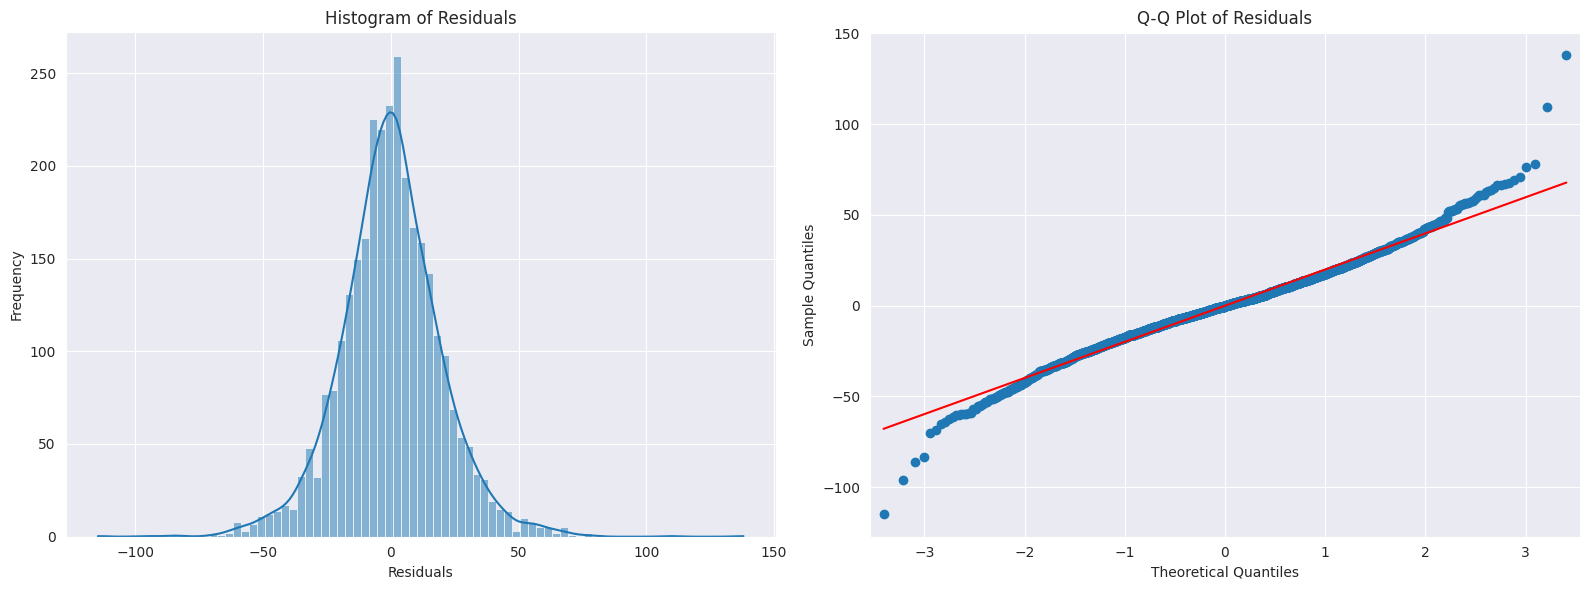

In [39]:
# Calculate residuals
residuals = res2.resid

fig, ax = plt.subplots(figsize=(16, 6), ncols = 2)
sns.histplot(residuals, kde=True, ax = ax[0])

ax[0].set_title('Histogram of Residuals')
ax[0].set_xlabel('Residuals')
ax[0].set_ylabel('Frequency')

sm.qqplot(residuals, line='s', ax = ax[1])
ax[1].set_title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()